In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [12]:
plt.rc("xtick", labelsize = 15, top = False, bottom = False, direction = "in")   
plt.rc("ytick", labelsize = 15, left = False, right = False, direction = "in")
plt.rc("axes", grid = False, linewidth = 1.2, axisbelow = True)
plt.rc("grid", ls = "dotted", lw = 1)     
plt.rc("font", size = 30, family = "serif", serif = ["Computer Modern Serif"])
plt.rc("text", usetex = True)
plt.rc("figure", figsize = (12, 6), dpi = 72)
plt.rc("ytick.major", width = 1)
plt.rc("xtick.major", width = 1)
plt.rc("legend", fontsize = 15, framealpha = 0.5, edgecolor = "black", fancybox = True)

In [13]:
data = pd.read_excel("../Data/Day 2/FaceRetarder.xlsx")

theta = data["Angle (deg)"] + 10 - 30 - 10
intensity = data["Intensity (V)"]

In [14]:
fit_func = lambda theta, I0, deltaPhi: I0 * (1 + np.cos(deltaPhi) * (np.cos(np.radians(theta))**2 - np.sin(np.radians(theta))**2))

p0 = [intensity.max() / 2, np.pi]

lower = [0, 0]
upper = [np.inf, 2*np.pi]

params, err = curve_fit(fit_func, theta, intensity, p0 = p0, bounds = (lower, upper), ftol=1e-12, xtol=1e-12, gtol=1e-12, maxfev = 10000)

print(params)

[5.05634489 5.0213686 ]


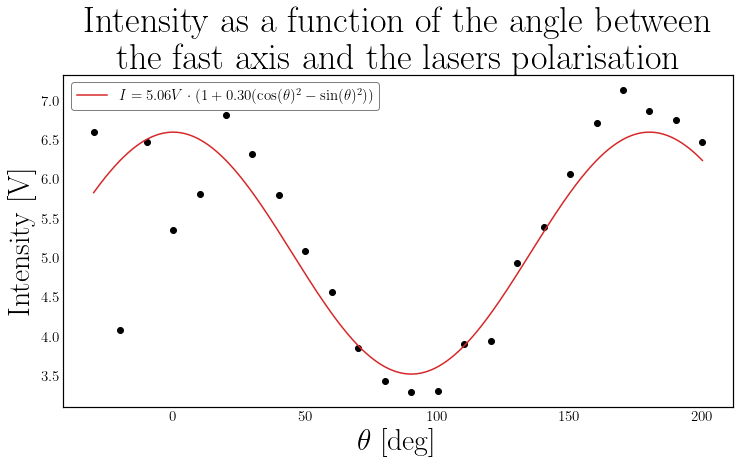

In [15]:
fig, ax = plt.subplots()

ax.plot(theta,intensity, "o", color = "black")

thetas = np.linspace(theta.min(), theta.max(), 1000)
ax.plot(thetas, fit_func(thetas, *params), color = "C3", label = f"$I = {params[0]:.2f} V \\cdot (1 + {np.cos(params[1]):.2f}(\\cos(\\theta)^2 - \\sin(\\theta)^2))$")

ax.set_title("Intensity as a function of the angle between \n the fast axis and the lasers polarisation")
ax.set_xlabel("$\\theta$ [deg]")
ax.set_ylabel("Intensity [V]")
ax.legend()